# Production Planning Optimization with Linear Programming (PuLP)

**Business problem:** *OakCraft Furniture* makes four products: chairs, tables, desks and shelves. Each product earns a different profit but consumes wood, labor hours and machine hours, and each resource is limited. Demand is also capped, and some minimum quantities are promised to contract customers.

**Goal:** decide how many units of each product to make next month to **maximize total profit**.

**Notebook outline**
1. Setup and data
2. Mathematical formulation
3. Building the model in PuLP
4. Solution
5. Resource utilization, shadow prices and reduced costs
6. What-if analysis
7. LP vs. whole-unit (integer) solution
8. Insights and recommendations

## 1. Setup and data

Install dependencies once (see `requirements.txt`): `pip install pulp pandas matplotlib jupyter`

In [1]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.2f}".format)
print("PuLP version:", pulp.__version__)

PuLP version: 2.9.0


In [2]:
# Product data (per unit)
products = pd.DataFrame({
    "product":      ["Chair", "Table", "Desk", "Shelf"],
    "profit":       [45, 120, 150, 60],      # $ per unit
    "wood":         [5, 20, 25, 8],          # board-feet per unit
    "labor":        [3, 8, 10, 4],           # labor hours per unit
    "machine":      [2, 5, 7, 3],            # machine hours per unit
    "min_units":    [20, 5, 0, 10],          # contractual minimum
    "max_units":    [120, 40, 30, 80],       # market demand cap
}).set_index("product")

# Monthly resource capacities
capacity = {"wood": 2200, "labor": 900, "machine": 600}

display(products)
print("Capacities:", capacity)

,profit,wood,labor,machine,min_units,max_units
product,,,,,,
Chair,45,5,3,2,20,120
Table,120,20,8,5,5,40
Desk,150,25,10,7,0,30
Shelf,60,8,4,3,10,80


Capacities: {'wood': 2200, 'labor': 900, 'machine': 600}


## 2. Mathematical formulation

**Decision variables:** $x_i \ge 0$ = units of product $i$ produced.

**Objective:** maximize profit

$$\max \sum_i p_i x_i$$

**Constraints**

- Resource limits, for each resource $r \in \{\text{wood, labor, machine}\}$: $\sum_i a_{ri} x_i \le C_r$
- Demand and contract bounds: $L_i \le x_i \le U_i$

This is a **linear program (LP)**: linear objective, linear constraints, continuous variables.

## 3. Building the model in PuLP

In [3]:
def build_and_solve(capacity, integer=False):
    """Build and solve the production-planning model. Returns (model, variables)."""
    cat = pulp.LpInteger if integer else pulp.LpContinuous
    model = pulp.LpProblem("OakCraft_Production_Plan", pulp.LpMaximize)

    # Decision variables with demand bounds built in
    x = {
        p: pulp.LpVariable(f"x_{p}", float(products.loc[p, "min_units"]),
                           float(products.loc[p, "max_units"]), cat)
        for p in products.index
    }

    # Objective
    model += pulp.lpSum(products.loc[p, "profit"] * x[p] for p in products.index), "Total_Profit"

    # Resource constraints
    for r, cap in capacity.items():
        model += (pulp.lpSum(products.loc[p, r] * x[p] for p in products.index) <= cap,
                  f"{r}_capacity")

    model.solve(pulp.PULP_CBC_CMD(msg=0))
    return model, x

model, x = build_and_solve(capacity)
print("Status:", pulp.LpStatus[model.status])

Status: Optimal


## 4. Solution

In [4]:
plan = pd.DataFrame({
    "units": {p: x[p].value() for p in x},
})
plan["profit_per_unit"] = products["profit"]
plan["total_profit"] = plan["units"] * plan["profit_per_unit"]
display(plan)
print(f"Maximum total profit: ${pulp.value(model.objective):,.2f}")

,units,profit_per_unit,total_profit
Chair,120.00,45,"5,400.00"
Table,40.00,120,"4,800.00"
Desk,18.00,150,"2,700.00"
Shelf,10.00,60,600.00


Maximum total profit: $13,500.00


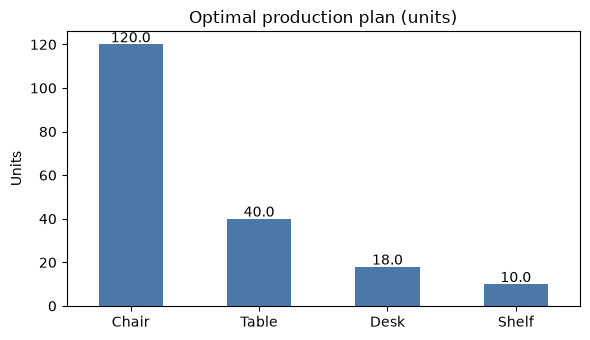

In [5]:
ax = plan["units"].plot(kind="bar", color="#4C78A8", figsize=(6, 3.5), rot=0)
ax.set_title("Optimal production plan (units)")
ax.set_ylabel("Units")
for i, v in enumerate(plan["units"]):
    ax.text(i, v + 1, f"{v:.1f}", ha="center")
plt.tight_layout(); plt.show()

## 5. Resource utilization, shadow prices and reduced costs

In [6]:
rows = []
for r, cap in capacity.items():
    c = model.constraints[f"{r}_capacity"]
    used = sum(products.loc[p, r] * x[p].value() for p in products.index)
    rows.append({"resource": r, "capacity": cap, "used": used,
                 "utilization_%": 100 * used / cap,
                 "slack": c.slack * -1 if c.slack < 0 else c.slack,
                 "shadow_price": c.pi})
util = pd.DataFrame(rows).set_index("resource")
display(util)

,capacity,used,utilization_%,slack,shadow_price
resource,,,,,
wood,2200,"1,930.00",87.73,270.00,-0.00
labor,900,900.00,100.00,-0.00,15.00
machine,600,596.00,99.33,4.00,-0.00


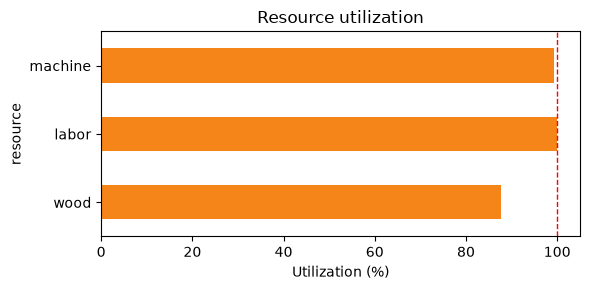

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
util["utilization_%"].plot(kind="barh", ax=ax, color="#F58518")
ax.axvline(100, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Utilization (%)"); ax.set_title("Resource utilization")
plt.tight_layout(); plt.show()

In [8]:
# Reduced costs: how much a product's profit must change before the plan changes
# (non-zero only when a variable sits at a bound)
rc = pd.DataFrame({
    "units": {p: x[p].value() for p in x},
    "reduced_cost": {p: x[p].dj for p in x},
    "at_min": {p: abs(x[p].value() - products.loc[p, "min_units"]) < 1e-6 for p in x},
    "at_max": {p: abs(x[p].value() - products.loc[p, "max_units"]) < 1e-6 for p in x},
})
display(rc)

,units,reduced_cost,at_min,at_max
Chair,120.00,-0.00,False,True
Table,40.00,-0.00,False,True
Desk,18.00,-0.00,False,False
Shelf,10.00,-0.00,True,False


**How to read this**
- **Shadow price** = extra profit from one more unit of a resource. A non-zero value means that resource is a *bottleneck*; zero means there is spare capacity.
- **Slack** = unused capacity.
- **Reduced cost** = for products at a bound, how the objective would move if that bound were relaxed by one unit.

## 6. What-if analysis

The shadow prices say which resource is worth expanding. Let's test it by sweeping capacity of each resource by -20% to +40% and tracking profit.

In [9]:
changes = [-0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.4]
records = []
for r in capacity:
    for ch in changes:
        cap = dict(capacity)
        cap[r] = capacity[r] * (1 + ch)
        m, _ = build_and_solve(cap)
        records.append({"resource": r, "change_%": ch * 100,
                        "status": pulp.LpStatus[m.status],
                        "profit": pulp.value(m.objective) if m.status == 1 else None})
sens = pd.DataFrame(records)
pivot = sens.pivot(index="change_%", columns="resource", values="profit")
display(pivot)

resource,labor,machine,wood
change_%,,,
-20.00,"10,800.00","11,014.29","13,200.00"
-10.00,"12,150.00","12,300.00","13,500.00"
0.00,"13,500.00","13,500.00","13,500.00"
10.00,"13,585.71","13,500.00","13,500.00"
20.00,"13,585.71","13,500.00","13,500.00"
30.00,"13,585.71","13,500.00","13,500.00"
40.00,"13,585.71","13,500.00","13,500.00"


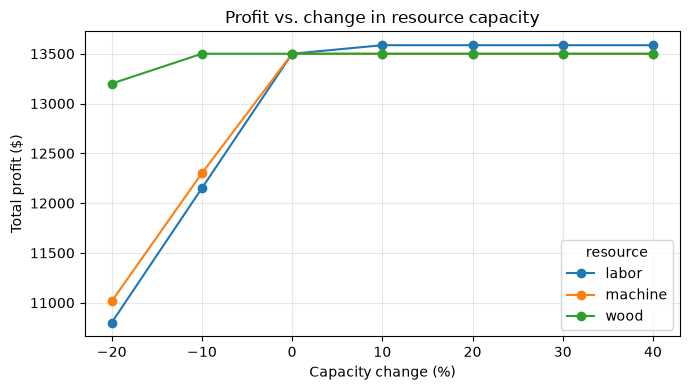

In [10]:
ax = pivot.plot(marker="o", figsize=(7, 4))
ax.set_title("Profit vs. change in resource capacity")
ax.set_xlabel("Capacity change (%)"); ax.set_ylabel("Total profit ($)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 7. LP solution vs. whole-unit (integer) solution

Furniture is made in whole units, so we re-solve with integer variables (an **integer program**) and see what rounding costs us.

In [11]:
model_int, x_int = build_and_solve(capacity, integer=True)
compare = pd.DataFrame({
    "LP units":      {p: x[p].value() for p in x},
    "Integer units": {p: x_int[p].value() for p in x_int},
})
display(compare)
lp_profit, ip_profit = pulp.value(model.objective), pulp.value(model_int.objective)
print(f"LP profit:      ${lp_profit:,.2f}")
print(f"Integer profit: ${ip_profit:,.2f}")
print(f"Cost of integrality: ${lp_profit - ip_profit:,.2f}")

,LP units,Integer units
Chair,120.00,120.00
Table,40.00,40.00
Desk,18.00,18.00
Shelf,10.00,10.00


LP profit:      $13,500.00
Integer profit: $13,500.00
Cost of integrality: $0.00


## 8. Insights and recommendations

In [12]:
binding = util[util["shadow_price"].abs() > 1e-6].sort_values("shadow_price", ascending=False)
idle = util[util["shadow_price"].abs() <= 1e-6]

print("KEY INSIGHTS")
print("-" * 60)
print(f"1. Best achievable monthly profit: ${ip_profit:,.0f} (whole units).")
print("2. Production mix:", ", ".join(f"{p} {x_int[p].value():.0f}" for p in x_int))
if len(binding):
    top = binding.index[0]
    print(f"3. Bottleneck: '{top}' - each extra unit is worth ${binding.iloc[0]['shadow_price']:.2f} in profit.")
    print("   Binding resources:", ", ".join(binding.index))
if len(idle):
    print("4. Spare capacity (no value in adding more):", ", ".join(idle.index))
capped = [p for p in x if abs(x[p].value() - products.loc[p, 'max_units']) < 1e-6]
if capped:
    print("5. Products selling at full demand:", ", ".join(capped))

KEY INSIGHTS
------------------------------------------------------------
1. Best achievable monthly profit: $13,500 (whole units).
2. Production mix: Chair 120, Table 40, Desk 18, Shelf 10
3. Bottleneck: 'labor' - each extra unit is worth $15.00 in profit.
   Binding resources: labor
4. Spare capacity (no value in adding more): wood, machine
5. Products selling at full demand: Chair, Table


### Recommendations
1. **Invest in the bottleneck resource first.** The shadow price and the what-if chart show where an extra unit of capacity pays off; resources with zero shadow price should not be expanded.
2. **Prioritize high profit-per-bottleneck-hour products.** Profit per unit alone is misleading; the model ranks products by contribution per scarce resource.
3. **Use the integer plan for execution.** The gap between the LP and integer solution is the (usually small) price of producing whole units.
4. **Re-run monthly.** Update `products` and `capacity` with real data; the model rebuilds the plan in milliseconds.

### Possible extensions
- Multi-period planning with inventory carry-over
- Setup costs via binary variables (fixed-charge model)
- Uncertain demand with scenario-based or robust optimization
- A Streamlit front end so planners can change inputs interactively